In [589]:
import pandas as pd
import numpy as np


from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor


In [590]:
df = pd.read_csv("../data/data_engineered.csv")

df.sort_values("shipped_date", ascending=True).head(10)

,sku,shipped_date,qty,month,day_of_week,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,rolling_mean_3,rolling_mean_5,rolling_mean_7,trend_7,growth_1,deviation_from_mean
0,017SAD,2021-01-15,75.0,1,4,0.0,0.0,0.0,0.0,0.0,75.0,0.0,0.000000,0.0,10.714286,0.0,0.000000,0.000000
79119,N3UHW5,2021-01-15,0.0,1,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000
79296,N3V9R2,2021-01-15,0.0,1,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000
79473,N7FEAT,2021-01-15,0.0,1,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000
79650,NDCP31,2021-01-15,0.0,1,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000
79827,NDRFT1,2021-01-15,0.0,1,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000
4425,1K0V6M,2021-01-15,38.0,1,4,0.0,38.0,38.0,0.0,38.0,0.0,76.0,25.333333,22.8,27.142857,-76.0,-0.974359,-25.333333
80004,NHTPU7,2021-01-15,0.0,1,4,0.0,51.0,0.0,0.0,0.0,0.0,34.0,17.000000,10.2,12.142857,-34.0,-0.980769,-17.000000
78942,N2HWE7,2021-01-15,0.0,1,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000
80181,NHURW5,2021-01-15,0.0,1,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000


In [591]:
df["shipped_date"] = pd.to_datetime(df["shipped_date"])

In [592]:
print(df.shape)
print(df.info())

(119652, 18)
<class 'pandas.DataFrame'>
RangeIndex: 119652 entries, 0 to 119651
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   sku                  119652 non-null  str           
 1   shipped_date         119652 non-null  datetime64[us]
 2   qty                  119652 non-null  float64       
 3   month                119652 non-null  int64         
 4   day_of_week          119652 non-null  int64         
 5   lag_1                119652 non-null  float64       
 6   lag_2                119652 non-null  float64       
 7   lag_3                119652 non-null  float64       
 8   lag_4                119652 non-null  float64       
 9   lag_5                119652 non-null  float64       
 10  lag_6                119652 non-null  float64       
 11  lag_7                119652 non-null  float64       
 12  rolling_mean_3       119652 non-null  float64       
 13  rolling_mean

In [593]:
#Sắp xếp dữ liệu theo thời gian
df = df.sort_values(
    ["shipped_date", "sku"]
).reset_index(drop=True)

In [594]:
df["qty_log"] = np.log1p(df["qty"])

In [595]:
# Xác định features và target
target="qty"
target_log = "qty_log"

features = [
    "month",
    "day_of_week",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "lag_5",
    "lag_6",
    "lag_7",
    "rolling_mean_3",
   #"rolling_mean_5",
   #"rolling_mean_7",
    "trend_7",
    "growth_1",
    "deviation_from_mean",
]


In [596]:
#Time-based train/test split
split_date = df["shipped_date"].quantile(0.8)

train = df[df["shipped_date"] <= split_date].copy()
test = df[df["shipped_date"] > split_date].copy()

print("Train:", train.shape)
print("Test:", test.shape)

Train: (95992, 19)
Test: (23660, 19)


In [597]:
#check the date range of train and test sets
print(
    "Train:",
    train["shipped_date"].min(),
    "→",
    train["shipped_date"].max()
)

print(
    "Test:",
    test["shipped_date"].min(),
    "→",
    test["shipped_date"].max()
)

Train: 2021-01-15 00:00:00 → 2021-10-24 00:00:00
Test: 2021-10-26 00:00:00 → 2022-01-02 00:00:00


In [598]:
x_train = train[features]
y_train = train[target]

x_test = test[features]
y_test = test[target]

* baseline

In [599]:
# 3. Moving Average Baseline
baseline_pred = test["rolling_mean_7"]

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_pred)
)

baseline_wmape = (
    np.sum(np.abs(y_test - baseline_pred))
    / np.sum(y_test)
)

baseline_r2 = r2_score(y_test, baseline_pred)

print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Baseline WMAPE: {baseline_wmape * 100:.2f}%")
print(f"Baseline R²: {baseline_r2:.4f}")

Baseline MAE: 74.40
Baseline RMSE: 319.36
Baseline WMAPE: 56.98%
Baseline R²: 0.6207


* Random Forest

In [600]:
y_train_log = train[target_log]
y_test_log = test[target_log]

In [601]:
#train a Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(x_train, y_train_log)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [602]:
#predict on the test set
rf_pred_log = rf_model.predict(x_test)
rf_pred = np.expm1(rf_pred_log)

In [603]:
#Evaluate the model
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_wmape = (np.sum(np.abs(y_test - rf_pred))/ np.sum(y_test))

rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest MAE: {rf_mae:.2f}")
print(f"Random Forest RMSE: {rf_rmse:.2f}")
print(f"Random Forest WMAPE: {rf_wmape * 100:.2f}%")
print(f"Random Forest R²: {rf_r2:.4f}")

Random Forest MAE: 71.70
Random Forest RMSE: 327.36
Random Forest WMAPE: 54.92%
Random Forest R²: 0.6015


In [604]:
predictions = test[["shipped_date", "sku"]].copy()

predictions["actual_qty"] = y_test.values
predictions["predicted_qty"] = rf_pred

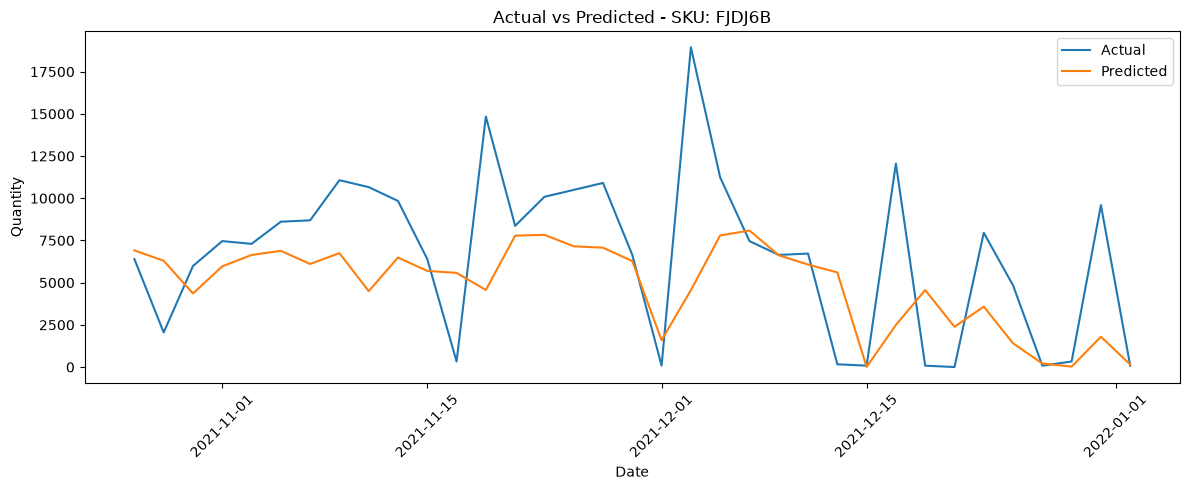

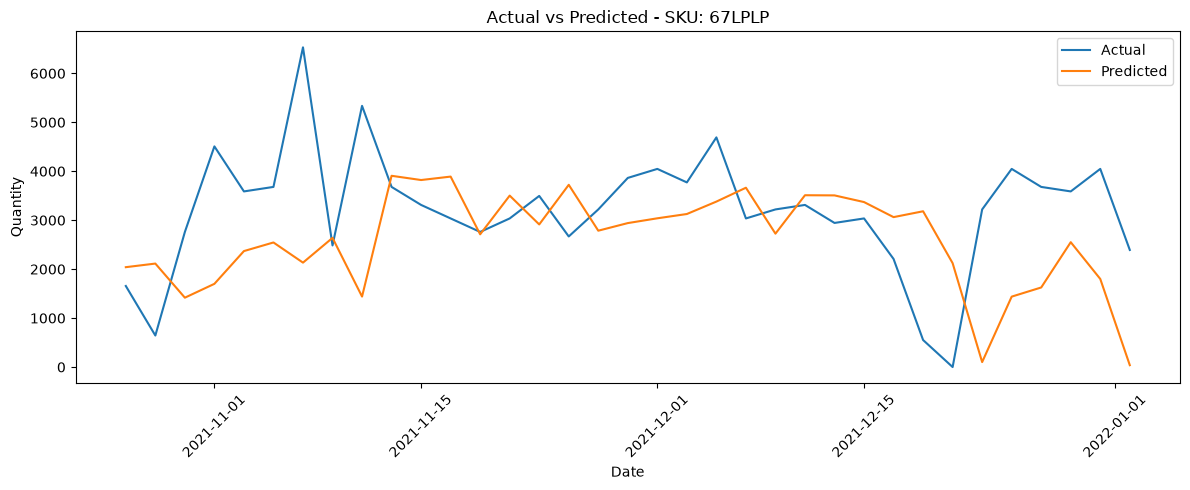

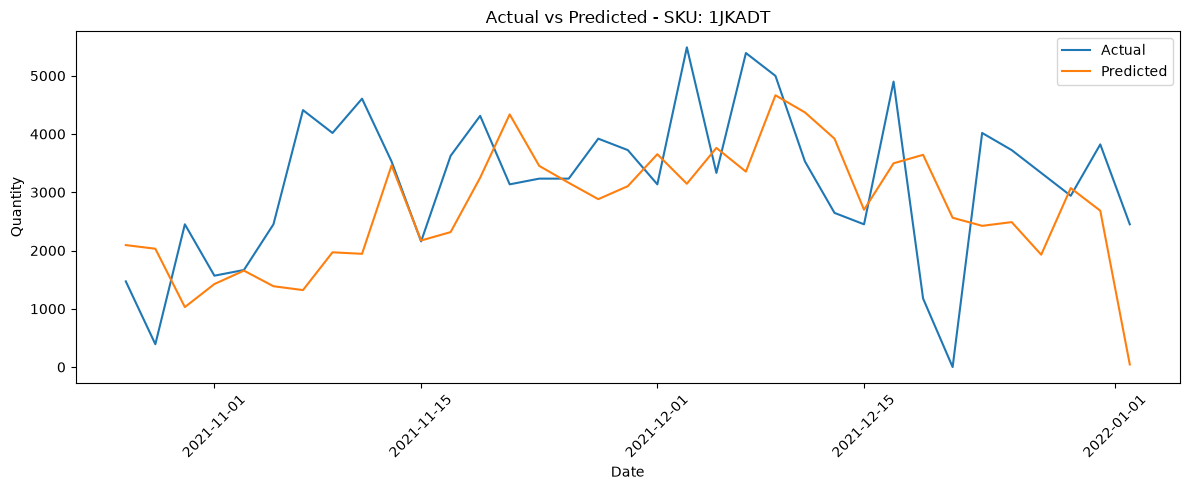

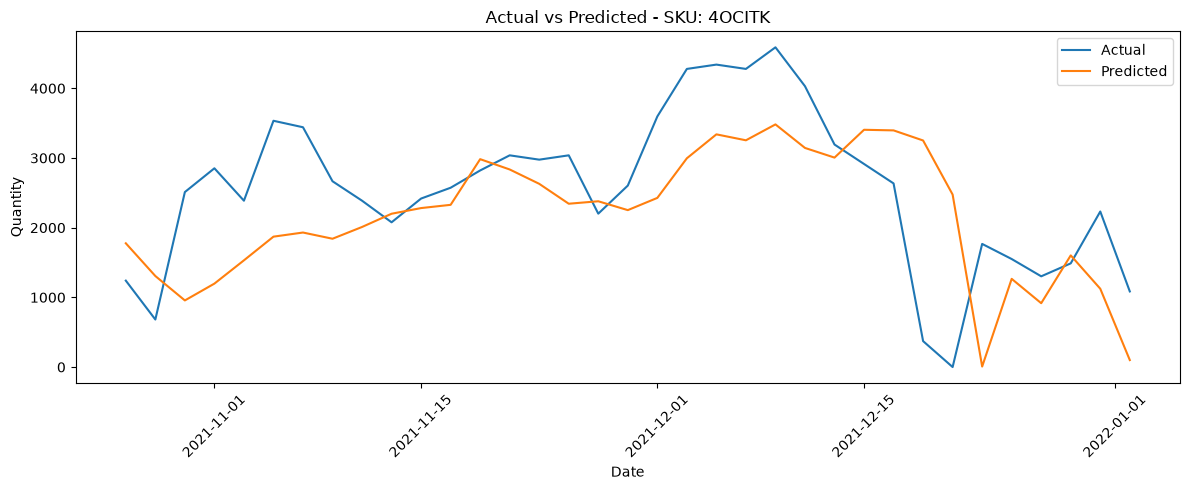

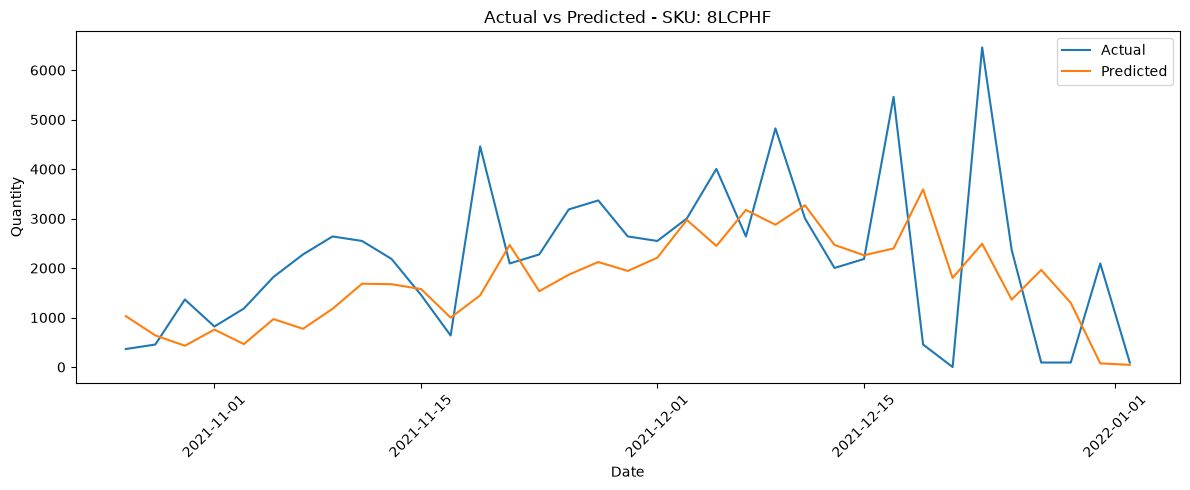

In [605]:
top_skus = (
    predictions.groupby("sku")["actual_qty"]
    .sum()
    .nlargest(5)
    .index
)

for sku in top_skus:
    sku_data = predictions[
        predictions["sku"] == sku
    ].sort_values("shipped_date")

    plt.figure(figsize=(12, 5))

    plt.plot(
        sku_data["shipped_date"],
        sku_data["actual_qty"],
        label="Actual"
    )

    plt.plot(
        sku_data["shipped_date"],
        sku_data["predicted_qty"],
        label="Predicted"
    )

    plt.title(f"Actual vs Predicted - SKU: {sku}")
    plt.xlabel("Date")
    plt.ylabel("Quantity")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [606]:
daily = (
    predictions.groupby("shipped_date")
    .agg(
        actual=("actual_qty", "sum"),
        predicted=("predicted_qty", "sum")
    )
    .reset_index()
    .sort_values("shipped_date")
)

In [607]:
daily = (
    predictions.groupby("shipped_date")
    .agg(
        actual=("actual_qty", "sum"),
        predicted=("predicted_qty", "sum")
    )
    .reset_index()
    .sort_values("shipped_date")
)

daily["predicted_shift_7"] = daily["predicted"].shift(-7)

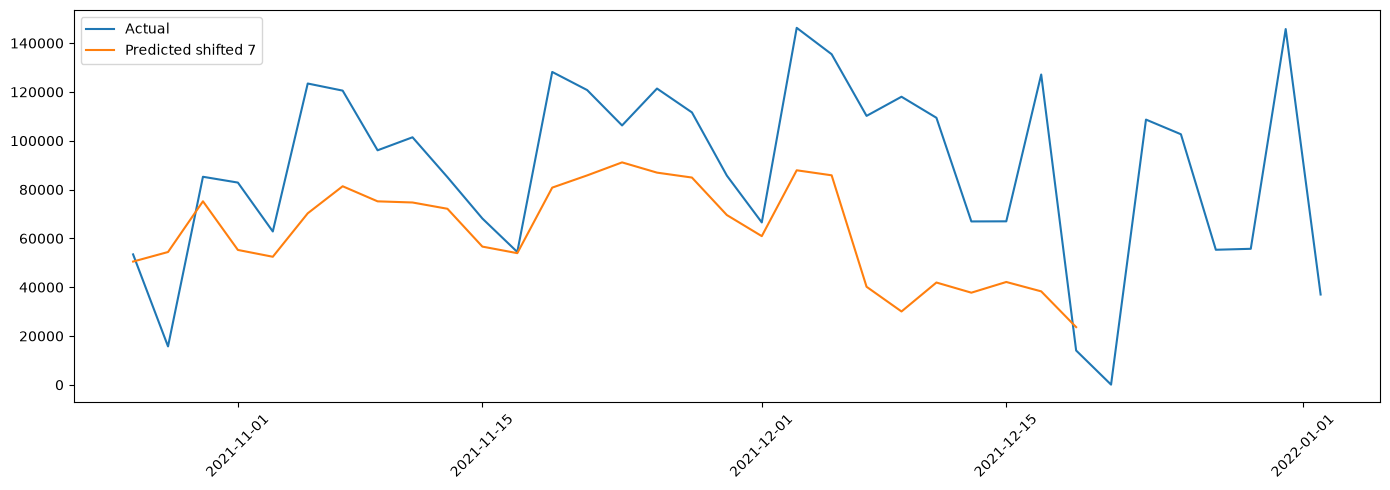

In [608]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily["shipped_date"],
    daily["actual"],
    label="Actual"
)

plt.plot(
    daily["shipped_date"],
    daily["predicted_shift_7"],
    label="Predicted shifted 7"
)

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

* LGBMRegressor


In [609]:
from lightgbm import LGBMRegressor

lgb_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(x_train, y_train_log)

lgb_pred_log = lgb_model.predict(x_test)

# Đưa prediction về lại scale qty
lgb_pred = np.expm1(lgb_pred_log)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003466 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2823
[LightGBM] [Info] Number of data points in the train set: 95992, number of used features: 13
[LightGBM] [Info] Start training from score 1.576087
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [610]:
lgb_mae = mean_absolute_error(y_test, lgb_pred)

lgb_rmse = np.sqrt(
    mean_squared_error(y_test, lgb_pred)
)

lgb_wmape = (
    np.sum(np.abs(y_test - lgb_pred))
    / np.sum(y_test)
)

lgb_r2 = r2_score(y_test, lgb_pred)

print(f"LightGBM MAE: {lgb_mae:.2f}")
print(f"LightGBM RMSE: {lgb_rmse:.2f}")
print(f"LightGBM WMAPE: {lgb_wmape:.2%}")
print(f"LightGBM R²: {lgb_r2:.4f}")

LightGBM MAE: 71.19
LightGBM RMSE: 342.84
LightGBM WMAPE: 54.53%
LightGBM R²: 0.5629


In [611]:
importance = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

importance

,feature,importance
9,rolling_mean_3,0.674259
8,lag_7,0.116732
7,lag_6,0.029004
5,lag_4,0.025635
0,month,0.024837
6,lag_5,0.024747
1,day_of_week,0.023642
10,trend_7,0.015194
12,deviation_from_mean,0.014846
11,growth_1,0.014628
